In [1]:
import sys, os
from pathlib import Path
_REPO_ROOT = Path.cwd()
while _REPO_ROOT != _REPO_ROOT.parent and not (_REPO_ROOT / 'minervachem' / '__init__.py').exists():
    _REPO_ROOT = _REPO_ROOT.parent
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from minervachem.multi_search.optimization.utils import ParetoFront
from minervachem.multi_search.dataset.qm9_toy.compute_pareto import get_pareto
from minervachem.multi_search.plot_utils import (
    plot_pareto_fronts, evaluate_pareto_quality,
    normalize_fronts, check_dominated, c_metric,
)


In [2]:
n = 0
PAPERRUNS_QM9 = 'paperruns/qm9'

meta_pf   = pd.read_csv(f'{PAPERRUNS_QM9}/qm9_meta_{n}_E_at_zvpe_e_gap_C_v/pareto_fronts.csv')
base_pf   = pd.read_csv(f'{PAPERRUNS_QM9}/qm9_base_{n}_E_at_zvpe_e_gap_C_v/pareto_fronts.csv')
random_pf = pd.read_csv(f'{PAPERRUNS_QM9}/qm9_random_{n}_E_at_zvpe_e_gap_C_v/pareto_fronts.csv')
df_list  = [meta_pf, base_pf, random_pf]
df_names = ['meta', 'base', 'random']

target_names = ['E_at', 'zvpe', 'e_gap', 'C_v']


In [3]:
pf_list = []
for df in df_list:
    last_gen = df['generation'].max()
    sub = df[df['generation'] == last_gen]
    Y = sub[target_names].to_numpy()
    smiles = sub['SMILES'].tolist()
    pf = ParetoFront()
    pf.initialize_pareto(X_list=[0.0]*len(Y), Y_list=Y, smiles_list=smiles)
    pf_list.append(pf)


In [4]:
actual_pf = get_pareto()
print(actual_pf.points)


[<minervachem.multi_search.optimization.utils.ParetoPoint object at 0xfaa31144c2b0>, <minervachem.multi_search.optimization.utils.ParetoPoint object at 0xfaa31144f430>, <minervachem.multi_search.optimization.utils.ParetoPoint object at 0xfaa31144d300>, <minervachem.multi_search.optimization.utils.ParetoPoint object at 0xfaa31144f220>, <minervachem.multi_search.optimization.utils.ParetoPoint object at 0xfaa31144fe50>, <minervachem.multi_search.optimization.utils.ParetoPoint object at 0xfaa31144c1f0>, <minervachem.multi_search.optimization.utils.ParetoPoint object at 0xfaa31144faf0>, <minervachem.multi_search.optimization.utils.ParetoPoint object at 0xfaa31144c7f0>, <minervachem.multi_search.optimization.utils.ParetoPoint object at 0xfaa31144ef20>, <minervachem.multi_search.optimization.utils.ParetoPoint object at 0xfaa31144fb20>, <minervachem.multi_search.optimization.utils.ParetoPoint object at 0xfaa31144e950>, <minervachem.multi_search.optimization.utils.ParetoPoint object at 0xfaa311

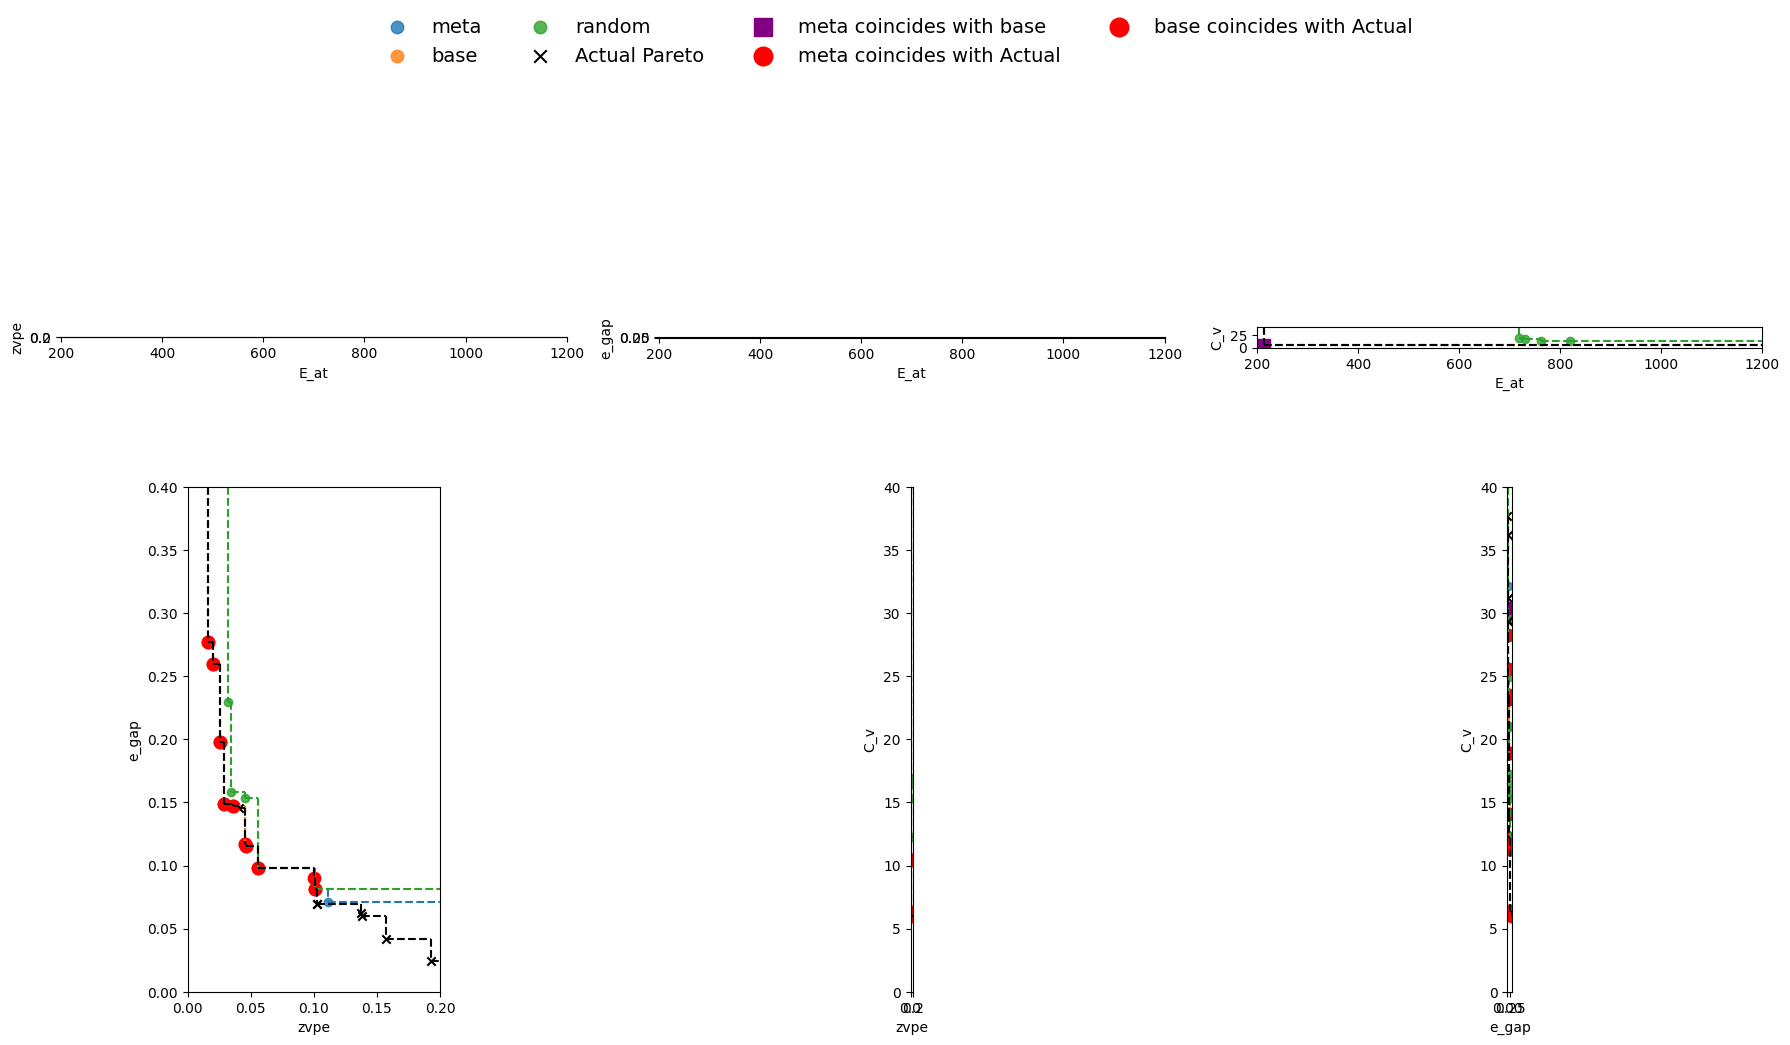

In [5]:
plot_pareto_fronts(
    pf_list=pf_list, actual_pf=actual_pf,
    exp_names=df_names, target_names=target_names,
    lim=[(200, 1200), (0.0, 0.2), (0.0, 0.4), (0, 40)],
)


In [6]:
for name, pf in zip(df_names, pf_list):
    metrics = evaluate_pareto_quality(pf_actual=pf, pf_reference=actual_pf)
    print(f"\n{name.upper()} vs ACTUAL:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")


(24, 4)
(34, 4)

META vs ACTUAL:
  hypervolume: 0.9019
  generational_distance: 0.0045
  inverted_generational_distance: 0.0475
  c_actual_dominates_pred: 0.0417
(20, 4)
(34, 4)

BASE vs ACTUAL:
  hypervolume: 0.9003
  generational_distance: 0.0000
  inverted_generational_distance: 0.0669
  c_actual_dominates_pred: 0.0000
(17, 4)
(34, 4)

RANDOM vs ACTUAL:
  hypervolume: 0.5419
  generational_distance: 0.1320
  inverted_generational_distance: 0.1885
  c_actual_dominates_pred: 0.8824


In [7]:
Y_meta   = pf_list[0].get_objectives()
Y_base   = pf_list[1].get_objectives()
Y_random = pf_list[2].get_objectives()
Y_actual = actual_pf.get_objectives()

print('Meta dominates base   :', c_metric(Y_meta, Y_base))
print('Meta dominates random :', c_metric(Y_meta, Y_random))
print('Base dominates meta   :', c_metric(Y_base, Y_meta))
print('Random dominates meta :', c_metric(Y_random, Y_meta))


Meta dominates base   : 0.0
Meta dominates random : 0.8235294117647058
Base dominates meta   : 0.0
Random dominates meta : 0.0


## Note

The original cell here compared two acquisition-function variants (`meta_ego_EI` vs `meta_ego_PI`). Those runs are not part of the `paperruns/qm9` release. To reproduce, run `experiment_qm9.py` once with `--acquisition ei` and once with `--acquisition pi`.


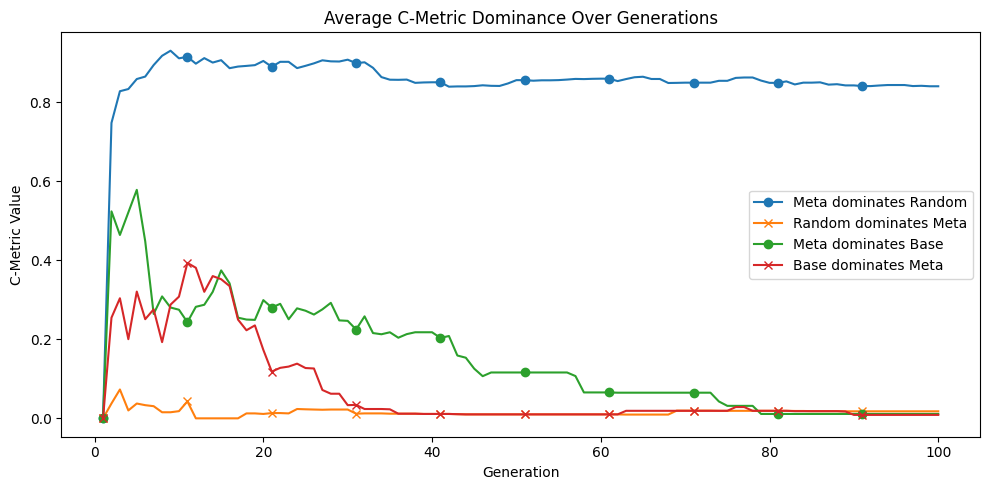

In [8]:
# Ensemble across 5 seeds.
meta_dom_random_all, meta_dom_base_all = [], []
base_dom_meta_all, random_dom_meta_all = [], []
MAX_GEN = 100
for n in range(5):
    meta_pf   = pd.read_csv(f'{PAPERRUNS_QM9}/qm9_meta_{n}_E_at_zvpe_e_gap_C_v/pareto_fronts.csv')
    base_pf   = pd.read_csv(f'{PAPERRUNS_QM9}/qm9_base_{n}_E_at_zvpe_e_gap_C_v/pareto_fronts.csv')
    random_pf = pd.read_csv(f'{PAPERRUNS_QM9}/qm9_random_{n}_E_at_zvpe_e_gap_C_v/pareto_fronts.csv')
    df_list_seed = [meta_pf, base_pf, random_pf]

    mvr, mvb, bvm, rvm = [], [], [], []
    for i in range(1, MAX_GEN + 1):
        Ys = []
        for df in df_list_seed:
            sub = df[df['generation'] == i]
            Ys.append(sub[target_names].to_numpy() if not sub.empty else np.empty((0, 4)))
        Y_meta, Y_base, Y_random = Ys
        if Y_meta.shape[0] == 0:
            mvr.append(0.0); rvm.append(0.0); mvb.append(0.0); bvm.append(0.0)
        else:
            mvr.append(c_metric(Y_meta, Y_random))
            rvm.append(c_metric(Y_random, Y_meta))
            mvb.append(c_metric(Y_meta, Y_base))
            bvm.append(c_metric(Y_base, Y_meta))
    meta_dom_random_all.append(mvr); meta_dom_base_all.append(mvb)
    base_dom_meta_all.append(bvm);   random_dom_meta_all.append(rvm)

meta_dom_random_avg = np.mean(meta_dom_random_all, axis=0)
meta_dom_base_avg   = np.mean(meta_dom_base_all, axis=0)
base_dom_meta_avg   = np.mean(base_dom_meta_all, axis=0)
random_dom_meta_avg = np.mean(random_dom_meta_all, axis=0)

generations = list(range(1, MAX_GEN + 1))
plt.figure(figsize=(10, 5))
plt.plot(generations, meta_dom_random_avg, label='Meta dominates Random', marker='o', markevery=10)
plt.plot(generations, random_dom_meta_avg, label='Random dominates Meta', marker='x', markevery=10)
plt.plot(generations, meta_dom_base_avg,   label='Meta dominates Base',   marker='o', markevery=10)
plt.plot(generations, base_dom_meta_avg,   label='Base dominates Meta',   marker='x', markevery=10)
plt.xlabel('Generation'); plt.ylabel('C-Metric Value')
plt.title('Average C-Metric Dominance Over Generations'); plt.legend()
plt.tight_layout(); plt.show()


Improvement from generation 1 to generation 101:
  E_at: 4.18 standard deviations
  zvpe: 3.26 standard deviations
  e_gap: 2.01 standard deviations
  C_v: 2.81 standard deviations


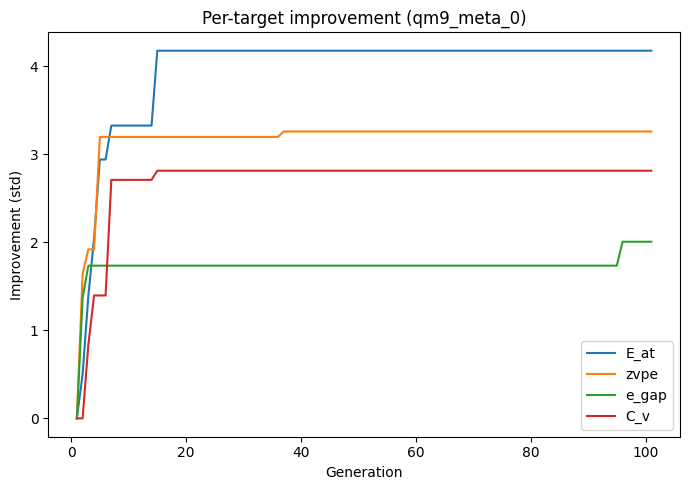

In [9]:
df = pd.read_csv(f'{PAPERRUNS_QM9}/qm9_meta_0_E_at_zvpe_e_gap_C_v/pareto_fronts.csv')
last_gen = int(df['generation'].max())

initial = df[df['generation'] == 1]
Y_initial = initial[target_names].to_numpy()
stds = np.std(Y_initial, axis=0)
best_initial = np.min(Y_initial, axis=0)

final = df[df['generation'] == last_gen]
Y_final = final[target_names].to_numpy()
best_final = np.min(Y_final, axis=0)
improvement_std = (best_initial - best_final) / np.where(stds == 0, 1, stds)
print(f'Improvement from generation 1 to generation {last_gen}:')
for i, t in enumerate(target_names):
    print(f'  {t}: {improvement_std[i]:.2f} standard deviations')

arr_improv = np.zeros((len(target_names), last_gen))
for k in range(1, last_gen + 1):
    cur = df[df['generation'] == k]
    if cur.empty: arr_improv[:, k-1] = np.nan; continue
    arr_improv[:, k-1] = (best_initial - np.min(cur[target_names].to_numpy(), axis=0)) / np.where(stds == 0, 1, stds)

plt.figure(figsize=(7, 5))
for i, t in enumerate(target_names):
    plt.plot(range(1, last_gen + 1), arr_improv[i], label=t)
plt.xlabel('Generation'); plt.ylabel('Improvement (std)')
plt.title('Per-target improvement (qm9_meta_0)')
plt.legend(); plt.tight_layout(); plt.show()


## Calibration trajectories

The original notebook compared `adaptive_sm_basic_F0`, `non_adaptive_F0`, and `fto_ADJ` runs — those experimental conditions aren't part of the `paperruns/qm9` release. The cells below have been adapted to use the meta-learner run that *is* shipped, reading `{target}_train_nse` and the per-target `*_base_train_rmse` / `*_meta_train_rmse` columns from `mse_models.csv` (only present in the meta run).


In [10]:
n_seed = 0
meta_mse = pd.read_csv(f'{PAPERRUNS_QM9}/qm9_meta_{n_seed}_E_at_zvpe_e_gap_C_v/mse_models.csv')
print('NSE columns :', [c for c in meta_mse.columns if 'nse' in c.lower()])


NSE columns : ['E_at_train_nse', 'zvpe_train_nse', 'e_gap_train_nse', 'C_v_train_nse']


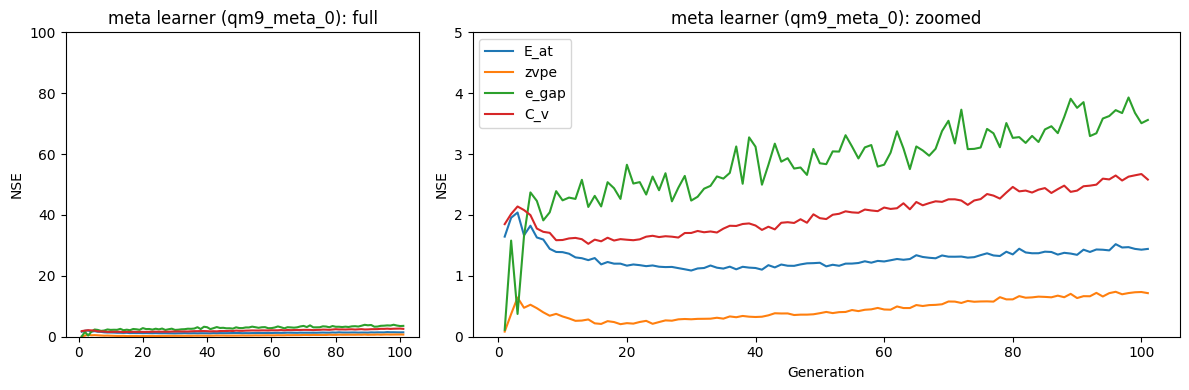

In [11]:
import matplotlib.gridspec as gridspec

def plot_nse(df_, title):
    fig = plt.figure(figsize=(12, 4))
    gs = gridspec.GridSpec(1, 2, width_ratios=[1, 2])
    ax1 = fig.add_subplot(gs[0]); ax2 = fig.add_subplot(gs[1])
    for t in target_names:
        col = f'{t}_train_nse'
        if col not in df_.columns: continue
        ax1.plot(df_['train_iteration'], df_[col], label=t)
        ax2.plot(df_['train_iteration'], df_[col], label=t)
    ax1.set_ylabel('NSE'); ax1.set_ylim(0, 100); ax1.set_title(f'{title}: full')
    ax2.set_xlabel('Generation'); ax2.set_ylabel('NSE'); ax2.set_ylim(0, 5)
    ax2.set_title(f'{title}: zoomed'); ax2.legend()
    plt.tight_layout(); plt.show()

plot_nse(meta_mse, 'meta learner (qm9_meta_0)')


In [12]:
block_size = 5

def compute_weights_from_calibs(calibs):
    err = np.abs(np.log(calibs + 1e-6))
    scores = 1.0 / (err + 1e-3)
    return scores / np.sum(scores, axis=0, keepdims=True)

def compute_weighted_calibrations(df_, target_names_, block_size=5):
    nse_cols = [f'{t}_train_nse' for t in target_names_]
    n_blocks = len(df_) // block_size
    out = []
    for i in range(n_blocks):
        block = df_.iloc[i*block_size:(i+1)*block_size][nse_cols].values
        w = compute_weights_from_calibs(block)
        out.append(np.sum(block * w, axis=0))
    return pd.DataFrame(out, columns=target_names_)

weighted_stats = compute_weighted_calibrations(meta_mse, target_names, block_size=5)
print('Weighted stats shape :', weighted_stats.shape)
print(weighted_stats.head())


Weighted stats shape : (20, 4)
       E_at      zvpe     e_gap       C_v
0  1.803492  0.505011  1.456072  2.009520
1  1.473706  0.391217  2.145477  1.669335
2  1.298078  0.268141  2.304125  1.590359
3  1.194961  0.228227  2.416442  1.593479
4  1.167514  0.235246  2.480898  1.623752


## Train RMSE: meta vs base

`mse_models.csv` in the meta-learner run includes both `*_base_train_rmse` and `*_meta_train_rmse` columns, so we can directly compare the two without loading the standalone base run.


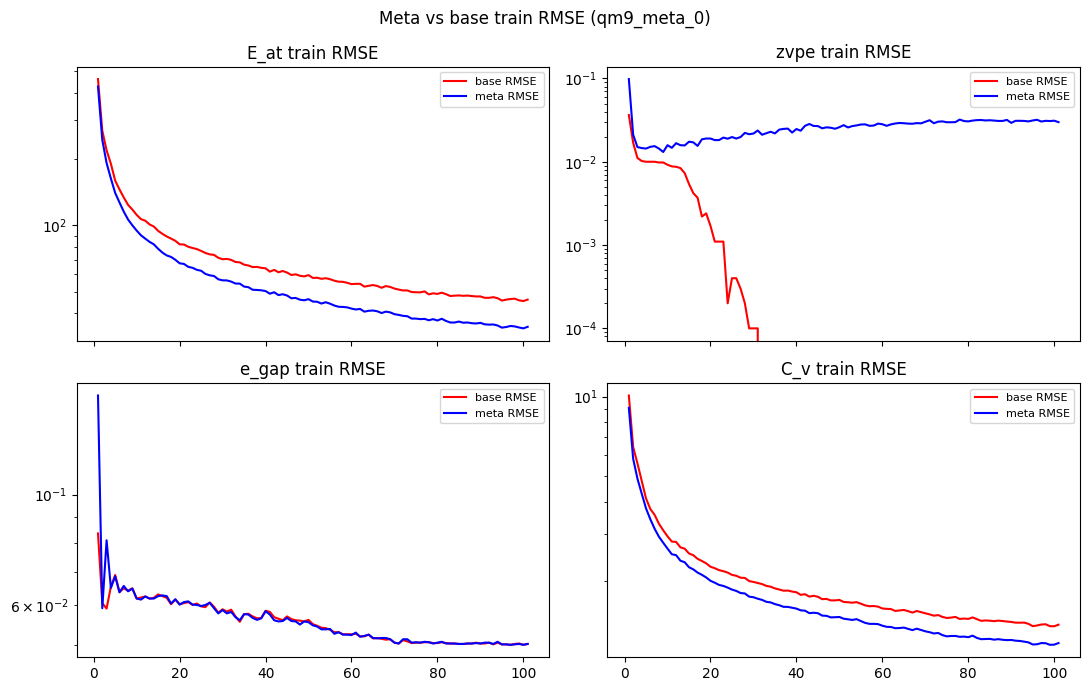

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for ax, t in zip(axes.flatten(), target_names):
    base_col = f'{t}_base_train_rmse'
    meta_col = f'{t}_meta_train_rmse'
    if base_col not in meta_mse.columns or meta_col not in meta_mse.columns:
        ax.set_title(f'{t}: columns missing'); continue
    ax.plot(meta_mse['train_iteration'], meta_mse[base_col], color='red',  label='base RMSE')
    ax.plot(meta_mse['train_iteration'], meta_mse[meta_col], color='blue', label='meta RMSE')
    ax.set_yscale('log'); ax.set_title(f'{t} train RMSE'); ax.legend(fontsize=8)
fig.suptitle('Meta vs base train RMSE (qm9_meta_0)')
fig.tight_layout(); plt.show()


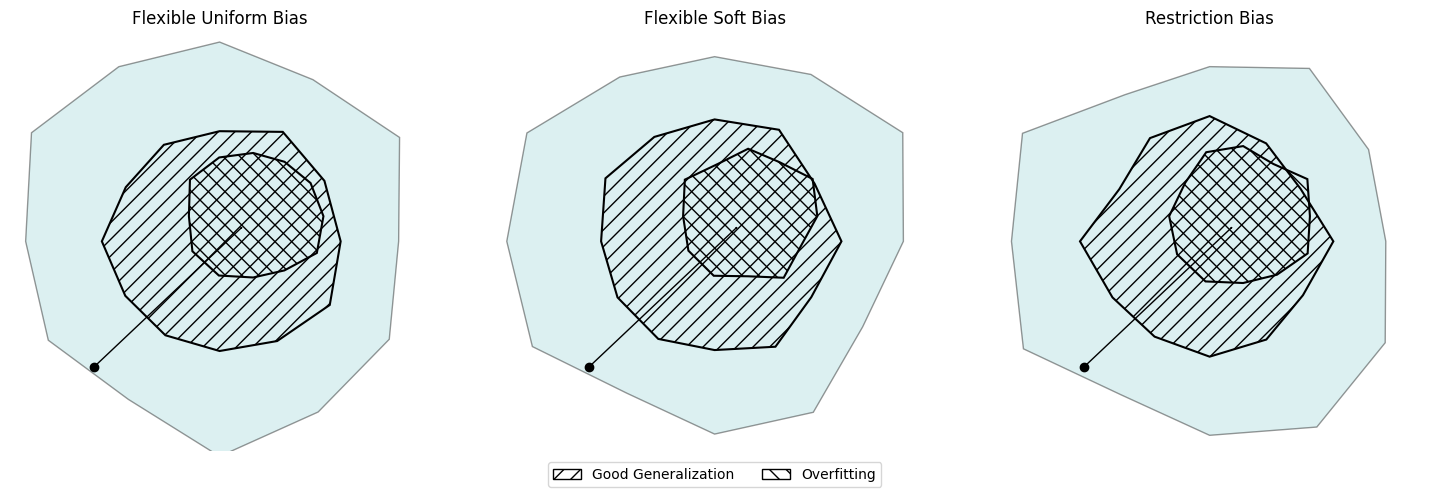

In [14]:
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch, FancyArrowPatch
from matplotlib.path import Path as MPath
import matplotlib.patches as mpatches
import numpy as np

def create_blobby_patch(center=(0, 0), scale=1.0, noise=0.3, n_points=12, **kwargs):
    angles = np.linspace(0, 2*np.pi, n_points, endpoint=False)
    radii = scale * (1 + noise * np.random.rand(n_points))
    vertices = [(center[0] + r * np.cos(a), center[1] + r * np.sin(a)) for r, a in zip(radii, angles)]
    vertices.append(vertices[0])
    codes = [MPath.MOVETO] + [MPath.LINETO]*(n_points - 1) + [MPath.CLOSEPOLY]
    return PathPatch(MPath(vertices, codes), **kwargs)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
titles = ['Flexible Uniform Bias', 'Flexible Soft Bias', 'Restriction Bias']
for ax, title in zip(axs, titles):
    ax.set_title(title); ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal'); ax.axis('off')
    ax.add_patch(create_blobby_patch(scale=2.0, facecolor='#a8dadc', alpha=0.4))
    ax.add_patch(create_blobby_patch(scale=1.2, facecolor='none', edgecolor='black', linewidth=1.5, hatch='//'))
    ax.add_patch(create_blobby_patch(center=(0.4, 0.3), scale=0.7, facecolor='none', edgecolor='black', linewidth=1.5, hatch='\\\\'))
    ax.plot(-1.5, -1.5, 'ko')
    ax.add_patch(FancyArrowPatch((-1.5, -1.5), (0.3, 0.2), arrowstyle='->', color='black'))

legend_patches = [
    mpatches.Patch(facecolor='none', edgecolor='black', hatch='//', label='Good Generalization'),
    mpatches.Patch(facecolor='none', edgecolor='black', hatch='\\\\', label='Overfitting'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=2)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()
